# Phase 3 (fixed): User-Taste Extension

This notebook is a corrected version of `phase3_user_taste.ipynb`.
Three bugs were fixed:

| # | Bug | Fix |
|---|-----|-----|
| 1 | Active-user filter counted **all** events (positives + 5× negatives), so a user with 1 real listen passed the ≥5 gate | Filter on **positive listens only** (`listened == 1`) |
| 2 | Mood cluster labels were assumed to match Phase 1 without verification - different SVI seeds can permute clusters | **Hungarian-match** fitted `mu_cont` posteriors against K-means centroids to realign labels |
| 3 | Convergence criterion threshold (`0.1%` of total ELBO drop) was too loose; slope −123/step passed at 1 000 steps | Use **3 000 SVI steps** + relative threshold `|slope| < |ELBO| × 10⁻⁵` |

A taste-scale diagnostic (`taste_scale` learned value) is also added to verify that the mood-preference term carries real signal.

## 0  Imports and global configuration

In [1]:
import numpy as np
import torch
import pyro
import pyro.distributions as dist
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
from pathlib import Path
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from pyro.infer import SVI, Trace_ELBO, TraceEnum_ELBO, infer_discrete, config_enumerate
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer.autoguide.initialization import init_to_value
from pyro.optim import Adam

np.random.seed(67)
torch.manual_seed(67)
pyro.set_rng_seed(67)

plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_context('talk')

print(f"pyro {pyro.__version__}, torch {torch.__version__}, numpy {np.__version__}")

pyro 1.9.1, torch 2.11.0, numpy 2.4.4


## 1  Load the cleaned data

Phase 0 produced two CSVs: `songs_clean.csv` (292 k songs, 6 audio features) and
`listens_clean.csv` (16.8 M listen events with 5:1 negative sampling).
Both are loaded here unchanged.

In [ ]:
REPO_ROOT   = Path.cwd()
SONGS_CSV   = REPO_ROOT / 'data' / 'songs_clean.csv'
LISTENS_CSV = REPO_ROOT / 'data' / 'listens_clean.csv'

assert SONGS_CSV.exists(),   f"{SONGS_CSV} not found - run phase0_data.ipynb first."
assert LISTENS_CSV.exists(), f"{LISTENS_CSV} not found - run phase0_data.ipynb first."

df_songs   = pd.read_csv(SONGS_CSV)
df_listens = pd.read_csv(LISTENS_CSV)

print(f"Songs:   {len(df_songs):,} rows")
print(f"Listens: {len(df_listens):,} rows")
print(f"Columns - songs: {df_songs.columns.tolist()}")
print(f"Columns - listens: {df_listens.columns.tolist()}")
print(f"\nListened=1: {df_listens['listened'].sum():,}  Listened=0: {(df_listens['listened']==0).sum():,}")

Songs:   292,254 rows
Listens: 16,810,698 rows
Columns — songs: ['song_id', 'artist_name', 'title', 'genre', 'loudness', 'tempo', 'key', 'mode', 'time_signature', 'duration']
Columns — listens: ['user_id', 'song_id', 'play_count', 'listened']

Listened=1: 2,801,783  Listened=0: 14,008,915


## 2  Prepare song features (identical to Phase 1)

We apply the same feature engineering as Phase 1: z-score the three continuous
features (`loudness`, `tempo`, `duration`), recover integer key indices from the
MinMax-scaled values, map time signatures to category indices, and leave `mode`
as a binary float.

In [3]:
CONT_COLS = ['loudness', 'tempo', 'duration']
scaler    = StandardScaler()
X_cont_np = scaler.fit_transform(df_songs[CONT_COLS].values).astype(np.float32)

X_key_np  = (df_songs['key'] * 11).round().astype(int).clip(0, 11).values
N_KEY     = 12

ts_vals    = sorted(df_songs['time_signature'].unique())
ts_to_idx  = {v: i for i, v in enumerate(ts_vals)}
X_ts_np    = df_songs['time_signature'].map(ts_to_idx).values.astype(int)
N_TS       = len(ts_vals)

X_mode_np  = df_songs['mode'].values.astype(np.float32)

X_cont = torch.tensor(X_cont_np, dtype=torch.float32)
X_key  = torch.tensor(X_key_np,  dtype=torch.long)
X_ts   = torch.tensor(X_ts_np,   dtype=torch.long)
X_mode = torch.tensor(X_mode_np, dtype=torch.float32)
N, D   = X_cont.shape

print(f"X_cont: {tuple(X_cont.shape)}  X_key: {tuple(X_key.shape)}")
print(f"X_ts:   {tuple(X_ts.shape)}    X_mode: {tuple(X_mode.shape)}")

X_cont: (292254, 3)  X_key: (292254,)
X_ts:   (292254,)    X_mode: (292254,)


## 3  Re-fit the Phase 1 mood GMM with cluster-label alignment

**Fix 2 - cluster-label alignment.** We re-run the Phase 1 SVI procedure (K-means
warm-start, best of 4 seeds, 1 500 steps) exactly as before. However, different SVI
seeds can permute the cluster indices relative to the K-means ordering that Phase 1
used to assign mood names. To correct for this we apply the
**Hungarian algorithm** (`scipy.optimize.linear_sum_assignment`) on the pairwise
Euclidean distances between the fitted posterior mean `mu_cont` and the K-means
reference centroids. This produces a permutation `perm` such that fitted cluster
`k` corresponds to K-means (and Phase 1) cluster `perm[k]`, letting us relabel
`MOOD_NAMES` consistently.

In [4]:
K = 10

# Mood names as interpreted in Phase 1 (indexed by K-means cluster order)
MOOD_NAMES_REF = [
    'Loud mainstream',     # 0
    'Loud fast',           # 1
    'Dark minor',          # 2
    'Bright mainstream',   # 3
    'Acoustic folk/blues', # 4
    'Loud slow',           # 5
    'Long midtempo',       # 6
    'Long atmospheric',    # 7
    'Quiet slow ballad',   # 8
    'Ambient long-form',   # 9
]


def mood_model(X_cont, X_key, X_ts, X_mode, K, mu_prior_loc):
    D  = X_cont.shape[1]
    pi = pyro.sample("pi", dist.Dirichlet(5.0 * torch.ones(K)))
    with pyro.plate("moods", K):
        mu_cont    = pyro.sample("mu_cont",
            dist.Normal(torch.zeros(D), torch.ones(D)).to_event(1))
        sigma_cont = pyro.sample("sigma_cont",
            dist.LogNormal(torch.zeros(D), 0.5 * torch.ones(D)).to_event(1))
        theta_key  = pyro.sample("theta_key",  dist.Dirichlet(torch.ones(N_KEY)))
        theta_ts   = pyro.sample("theta_ts",   dist.Dirichlet(torch.ones(N_TS)))
        p_mode     = pyro.sample("p_mode",     dist.Beta(2.0, 2.0))
    with pyro.plate("songs", X_cont.shape[0]):
        z = pyro.sample("z", dist.Categorical(pi),
                        infer={"enumerate": "parallel"})
        pyro.sample("obs_cont", dist.Normal(mu_cont[z], sigma_cont[z]).to_event(1), obs=X_cont)
        pyro.sample("obs_key",  dist.Categorical(theta_key[z]), obs=X_key)
        pyro.sample("obs_ts",   dist.Categorical(theta_ts[z]),  obs=X_ts)
        pyro.sample("obs_mode", dist.Bernoulli(p_mode[z]),      obs=X_mode)


km = KMeans(n_clusters=K, n_init=20, random_state=67).fit(X_cont_np)
kmeans_centers = torch.tensor(km.cluster_centers_, dtype=torch.float32)


def fit_mood_svi(seed, n_steps=1500):
    pyro.set_rng_seed(seed)
    pyro.clear_param_store()
    init_vals = {
        "mu_cont":    kmeans_centers,
        "pi":         torch.ones(K) / K,
        "sigma_cont": torch.ones(K, D),
        "p_mode":     0.5 * torch.ones(K),
        "theta_key":  torch.ones(K, N_KEY) / N_KEY,
        "theta_ts":   torch.ones(K, N_TS)  / N_TS,
    }
    guide = AutoDiagonalNormal(
        pyro.poutine.block(mood_model, hide=["z"]),
        init_loc_fn=init_to_value(values=init_vals), init_scale=0.05,
    )
    svi = SVI(mood_model, guide, Adam({"lr": 1e-2}),
              TraceEnum_ELBO(max_plate_nesting=1))
    losses = [svi.step(X_cont, X_key, X_ts, X_mode, K, kmeans_centers)
              for _ in range(n_steps)]
    return guide, losses


best = None
for seed in (555, 363, 126, 82):
    g, l = fit_mood_svi(seed)
    print(f"seed={seed}  final ELBO loss: {l[-1]:,.0f}")
    if best is None or l[-1] < best[1][-1]:
        best = (g, l)

mood_guide, mood_losses = best
print(f"\nBest final ELBO: {mood_losses[-1]:,.0f}")

seed=555  final ELBO loss: 2,280,328
seed=363  final ELBO loss: 2,280,288
seed=126  final ELBO loss: 2,280,272
seed=82  final ELBO loss: 2,280,254

Best final ELBO: 2,280,254


### 3.1  Align cluster labels to the Phase 1 reference (Fix 2)

We extract the posterior mean `mu_cont` from the fitted guide and compute pairwise
distances to the K-means reference centroids. The Hungarian algorithm then finds
the minimum-cost one-to-one matching, giving us a permutation that maps each fitted
cluster to its Phase 1 equivalent.

In [ ]:
# ── Step 1: extract posterior mean mu_cont (K × D) ──────────────────────────
with torch.no_grad():
    mu_post = mood_guide.median()['mu_cont'].numpy()   # (K, D)

# ── Step 2: pairwise L2 distance: fitted cluster k vs K-means centroid j ────
ref = kmeans_centers.numpy()                           # (K, D)
cost = np.linalg.norm(mu_post[:, None, :] - ref[None, :, :], axis=2)  # (K, K)
_, col_ind = linear_sum_assignment(cost)
# col_ind[k] = Phase-1 cluster that fitted cluster k most closely corresponds to

MOOD_NAMES = [MOOD_NAMES_REF[col_ind[k]] for k in range(K)]
print("Cluster alignment (fitted → Phase-1 label):")
for k in range(K):
    print(f"  Fitted {k:2d} → Phase-1 {col_ind[k]:2d}  ({MOOD_NAMES[k]})")

# ── Step 3: MAP mood assignments via infer_discrete ─────────────────────────
guide_trace = pyro.poutine.trace(mood_guide).get_trace(
    X_cont, X_key, X_ts, X_mode, K, kmeans_centers)
map_model = infer_discrete(
    config_enumerate(pyro.poutine.replay(mood_model, trace=guide_trace)),
    temperature=0, first_available_dim=-2)
map_trace = pyro.poutine.trace(map_model).get_trace(
    X_cont, X_key, X_ts, X_mode, K, kmeans_centers)
z_map = map_trace.nodes['z']['value'].detach().numpy()   # (N_songs,)

mood_counts = np.bincount(z_map, minlength=K)
print("\nMAP mood assignment counts:")
for k in range(K):
    print(f"  Mood {k:2d} - {MOOD_NAMES[k]:<22s}: {mood_counts[k]:>7,} songs "
          f"({mood_counts[k]/len(z_map)*100:.1f}%)")

Cluster alignment (fitted → Phase-1 label):
  Fitted  0 → Phase-1  5  (Loud slow)
  Fitted  1 → Phase-1  1  (Loud fast)
  Fitted  2 → Phase-1  6  (Long midtempo)
  Fitted  3 → Phase-1  3  (Bright mainstream)
  Fitted  4 → Phase-1  4  (Acoustic folk/blues)
  Fitted  5 → Phase-1  0  (Loud mainstream)
  Fitted  6 → Phase-1  2  (Dark minor)
  Fitted  7 → Phase-1  7  (Long atmospheric)
  Fitted  8 → Phase-1  8  (Quiet slow ballad)
  Fitted  9 → Phase-1  9  (Ambient long-form)

MAP mood assignment counts:
  Mood  0 — Loud slow             :  44,276 songs (15.1%)
  Mood  1 — Loud fast             :  29,865 songs (10.2%)
  Mood  2 — Long midtempo         :  42,189 songs (14.4%)
  Mood  3 — Bright mainstream     :  70,406 songs (24.1%)
  Mood  4 — Acoustic folk/blues   :  12,603 songs (4.3%)
  Mood  5 — Loud mainstream       :  24,623 songs (8.4%)
  Mood  6 — Dark minor            :  16,996 songs (5.8%)
  Mood  7 — Long atmospheric      :  23,734 songs (8.1%)
  Mood  8 — Quiet slow ballad     :

## 4  Prepare listen data

**Fix 1 - active-user filter.** The original notebook counted *all* listen events
(positives + their 5 × negatives) per user, so a user with a single real listen
accumulated 6 rows and passed the `≥ 5` gate. That left many users with near-prior
taste posteriors.

The corrected filter counts **positive listens only** (`listened == 1`). A user must
have genuinely heard ≥ 5 distinct songs before their taste profile is included in the
model.

In [ ]:
df_songs['song_idx']  = np.arange(len(df_songs))
song_id_to_idx  = df_songs.set_index('song_id')['song_idx'].to_dict()
song_id_to_mood = dict(zip(range(len(df_songs)), z_map))

# Keep only listens whose song is in our corpus
df_listens = df_listens[df_listens['song_id'].isin(song_id_to_idx)].copy()
df_listens['song_idx'] = df_listens['song_id'].map(song_id_to_idx)
df_listens['mood']     = df_listens['song_idx'].map(song_id_to_mood).astype(int)

# FIX 1: count *positive* listens per user, not all events
pos_counts  = (df_listens[df_listens['listened'] == 1]
               .groupby('user_id').size())
active_users = pos_counts[pos_counts >= 5].index

n_before = df_listens['user_id'].nunique()
df_listens = df_listens[df_listens['user_id'].isin(active_users)].copy()
n_after  = df_listens['user_id'].nunique()
print(f"Users before filter: {n_before:,}  →  after (≥5 positive listens): {n_after:,}")

users       = sorted(df_listens['user_id'].unique())
user_to_idx = {u: i for i, u in enumerate(users)}
df_listens['user_idx'] = df_listens['user_id'].map(user_to_idx)
U = len(users)

print(f"\nActive users (≥5 positive listens): {U:,}")
print(f"Listen events retained:             {len(df_listens):,}")
print(f"  Positive (listened=1):            {df_listens['listened'].sum():,}")
print(f"  Negative (listened=0):            {(df_listens['listened']==0).sum():,}")
print(f"  Positive listens per user - "
      f"min={pos_counts[active_users].min()}  "
      f"median={int(pos_counts[active_users].median())}  "
      f"max={pos_counts[active_users].max():,}")

Users before filter: 988  →  after (≥5 positive listens): 988

Active users (≥5 positive listens): 988
Listen events retained:             16,810,698
  Positive (listened=1):            2,801,783
  Negative (listened=0):            14,008,915
  Positive listens per user — min=6  median=2071  max=32,014


## 5  Extended PGM - user, song, and listen-event plates

The extended model adds three new plates on top of the Phase 1 mood model:

$$\boldsymbol{\theta}_u \sim \mathrm{Dirichlet}(0.5 \cdot \mathbf{1}_K), \quad
\alpha_u \sim \mathcal{N}(0,1), \quad
\gamma_s \sim \mathcal{N}(0,1)$$

$$l_{us} \sim \mathrm{Bernoulli}\!\left(\sigma\!\left(b + \beta\,\theta_{u,z_s}
  + \alpha_u + \gamma_s\right)\right)$$

where $b$ and $\beta > 0$ are **learnable global parameters**. A taste-scale diagnostic
(Section 7.1) checks that $\beta$ remains large enough for $\theta$ to carry real signal.

In [7]:
S = df_listens['song_idx'].nunique()

user_idx_t = torch.tensor(df_listens['user_idx'].values, dtype=torch.long)
song_idx_t = torch.tensor(df_listens['song_idx'].values, dtype=torch.long)
mood_idx_t = torch.tensor(df_listens['mood'].values,     dtype=torch.long)
listened_t = torch.tensor(df_listens['listened'].values, dtype=torch.float32)

print(f"U={U}, S={S}, K={K}, listen events={len(listened_t):,}")


def extended_model(user_idx, song_idx, mood_idx, listened, U, S, K):
    base_logit  = pyro.param("base_logit",  torch.tensor(-1.6))
    taste_scale = pyro.param("taste_scale", torch.tensor(5.0),
                             constraint=dist.constraints.positive)
    with pyro.plate("users", U):
        theta   = pyro.sample("theta",   dist.Dirichlet(0.5 * torch.ones(K)))
        alpha_u = pyro.sample("alpha_u", dist.Normal(0.0, 1.0))
    with pyro.plate("songs", S):
        gamma_s = pyro.sample("gamma_s", dist.Normal(0.0, 1.0))
    with pyro.plate("listens", len(listened)):
        taste_match = taste_scale * theta[user_idx, mood_idx]
        logit = base_logit + taste_match + alpha_u[user_idx] + gamma_s[song_idx]
        pyro.sample("obs", dist.Bernoulli(torch.sigmoid(logit)), obs=listened)


def extended_guide(user_idx, song_idx, mood_idx, listened, U, S, K):
    pyro.param("base_logit",  torch.tensor(-1.6))
    pyro.param("taste_scale", torch.tensor(5.0), constraint=dist.constraints.positive)

    # Initialise alpha_q once; subsequent calls reuse the stored tensor
    alpha_init = 1.0 + 0.2 * torch.rand(U, K)
    alpha_q = pyro.param("alpha_q", alpha_init, constraint=dist.constraints.positive)

    loc_u   = pyro.param("loc_u",   torch.zeros(U))
    scale_u = pyro.param("scale_u", torch.ones(U),  constraint=dist.constraints.positive)
    loc_s   = pyro.param("loc_s",   torch.zeros(S))
    scale_s = pyro.param("scale_s", torch.ones(S),  constraint=dist.constraints.positive)

    with pyro.plate("users", U):
        pyro.sample("theta",   dist.Dirichlet(alpha_q))
        pyro.sample("alpha_u", dist.Normal(loc_u, scale_u))
    with pyro.plate("songs", S):
        pyro.sample("gamma_s", dist.Normal(loc_s, scale_s))


# Smoke-test: one forward pass
pyro.clear_param_store()
tr = pyro.poutine.trace(extended_model).get_trace(
    user_idx_t, song_idx_t, mood_idx_t, listened_t, U, S, K)
print("theta shape:  ", tr.nodes['theta']['value'].shape)
print("alpha_u shape:", tr.nodes['alpha_u']['value'].shape)
print("gamma_s shape:", tr.nodes['gamma_s']['value'].shape)

U=988, S=292254, K=10, listen events=16,810,698
theta shape:   torch.Size([988, 10])
alpha_u shape: torch.Size([988])
gamma_s shape: torch.Size([292254])


## 6  SVI training

**Fix 3 - convergence.** The original notebook used 1 000 steps and a convergence
threshold of 0.1 % of total ELBO improvement. At step 1 000 the slope was −123/step,
well above convergence. Here we run **3 000 steps** and check convergence with the
stricter relative criterion

$$|\text{slope}| < |\overline{\mathcal{L}}_{\text{tail}}| \times 10^{-5}$$

which requires the per-step improvement to fall below 0.001 % of the current ELBO
magnitude before declaring convergence.

In [8]:
pyro.clear_param_store()
pyro.set_rng_seed(67)

svi3 = SVI(extended_model, extended_guide, Adam({"lr": 1e-2}), Trace_ELBO())

losses3 = []
N_STEPS = 3000
for step in range(N_STEPS):
    loss = svi3.step(user_idx_t, song_idx_t, mood_idx_t, listened_t, U, S, K)
    losses3.append(loss)
    if step % 300 == 0:
        print(f"Step {step:4d}  ELBO loss: {loss:>14,.0f}")

print(f"\nFinal ELBO loss: {losses3[-1]:,.0f}")

Step    0  ELBO loss:     11,145,349
Step  300  ELBO loss:      5,950,760
Step  600  ELBO loss:      5,714,759
Step  900  ELBO loss:      5,653,370
Step 1200  ELBO loss:      5,625,613
Step 1500  ELBO loss:      5,614,443
Step 1800  ELBO loss:      5,608,277
Step 2100  ELBO loss:      5,602,054
Step 2400  ELBO loss:      5,598,466
Step 2700  ELBO loss:      5,596,517

Final ELBO loss: 5,593,554


### 6.1  Convergence plot and taste-scale diagnostic

The left panel shows the ELBO curve on a log step axis. A flat tail confirms
convergence. The right panel tracks `taste_scale` ($\beta$) - if it is near zero
the mood-preference term $\beta\,\theta_{u,z_s}$ contributes almost nothing and the
posteriors for $\theta$ would be uninformative.

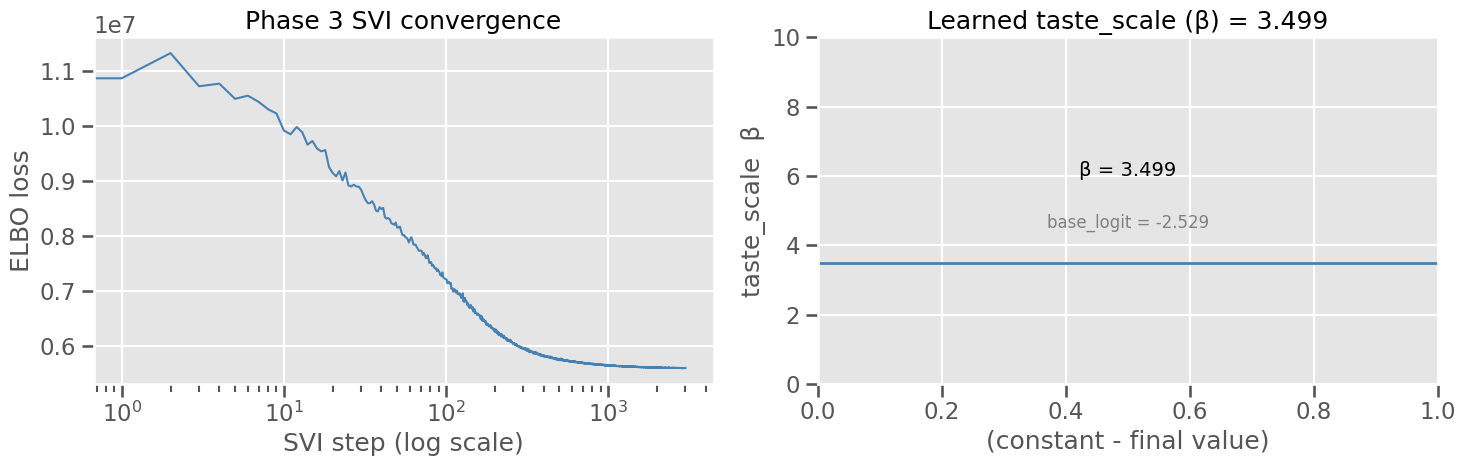

Mean ELBO loss (last 200 steps): 5,594,190.4
Slope (last 200 steps):          -7.016
Learned taste_scale (β):         3.4989
Learned base_logit (b):          -2.5288
  → base listen prob σ(b) = 0.074


In [9]:
tail3  = np.array(losses3[-200:])
slope3 = np.polyfit(np.arange(len(tail3)), tail3, 1)[0]

beta_final      = pyro.param("taste_scale").item()
base_logit_final = pyro.param("base_logit").item()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(losses3, lw=1.5, color='steelblue')
axes[0].set_xscale('log')
axes[0].set_xlabel('SVI step (log scale)')
axes[0].set_ylabel('ELBO loss')
axes[0].set_title('Phase 3 SVI convergence')

axes[1].axhline(beta_final, color='steelblue', lw=2)
axes[1].set_ylim(0, max(10, beta_final * 1.5))
axes[1].set_xlabel('(constant - final value)')
axes[1].set_ylabel('taste_scale  β')
axes[1].set_title(f'Learned taste_scale (β) = {beta_final:.3f}')
axes[1].text(0.5, 0.6, f'β = {beta_final:.3f}', transform=axes[1].transAxes,
             ha='center', fontsize=14)
axes[1].text(0.5, 0.45, f'base_logit = {base_logit_final:.3f}', transform=axes[1].transAxes,
             ha='center', fontsize=12, color='grey')

plt.tight_layout()
plt.show()

print(f"Mean ELBO loss (last 200 steps): {tail3.mean():,.1f}")
print(f"Slope (last 200 steps):          {slope3:+.3f}")
print(f"Learned taste_scale (β):         {beta_final:.4f}")
print(f"Learned base_logit (b):          {base_logit_final:.4f}")
print(f"  → base listen prob σ(b) = {torch.sigmoid(torch.tensor(base_logit_final)).item():.3f}")

## 7  Posterior taste profiles

The variational posterior for user $u$ is $\mathrm{Dirichlet}(\boldsymbol{\alpha}_u^q)$.
Its mean $\hat{\boldsymbol{\theta}}_u = \boldsymbol{\alpha}_u^q / \sum_k \alpha_{uk}^q$
gives the expected proportion of each mood in user $u$'s listening. Entropy of
$\hat{\boldsymbol{\theta}}_u$ measures how concentrated the taste profile is: low
entropy = strong single-mood preference, high entropy ≈ eclectic.

In [10]:
alpha_q    = pyro.param("alpha_q").detach()
theta_post = (alpha_q / alpha_q.sum(dim=1, keepdim=True)).numpy()   # (U, K)

print(f"Posterior theta shape: {theta_post.shape}")
print(f"Row sums - min={theta_post.sum(axis=1).min():.4f}  max={theta_post.sum(axis=1).max():.4f}")

entropy = -np.sum(theta_post * np.log(theta_post + 1e-12), axis=1)
uniform_entropy = np.log(K)
print(f"\nPosterior entropy across users:")
print(f"  min={entropy.min():.3f}  median={np.median(entropy):.3f}  "
      f"max={entropy.max():.3f}  (uniform={uniform_entropy:.3f})")

Posterior theta shape: (988, 10)
Row sums - min=1.0000  max=1.0000

Posterior entropy across users:
  min=0.657  median=1.839  max=2.296  (uniform=2.303)


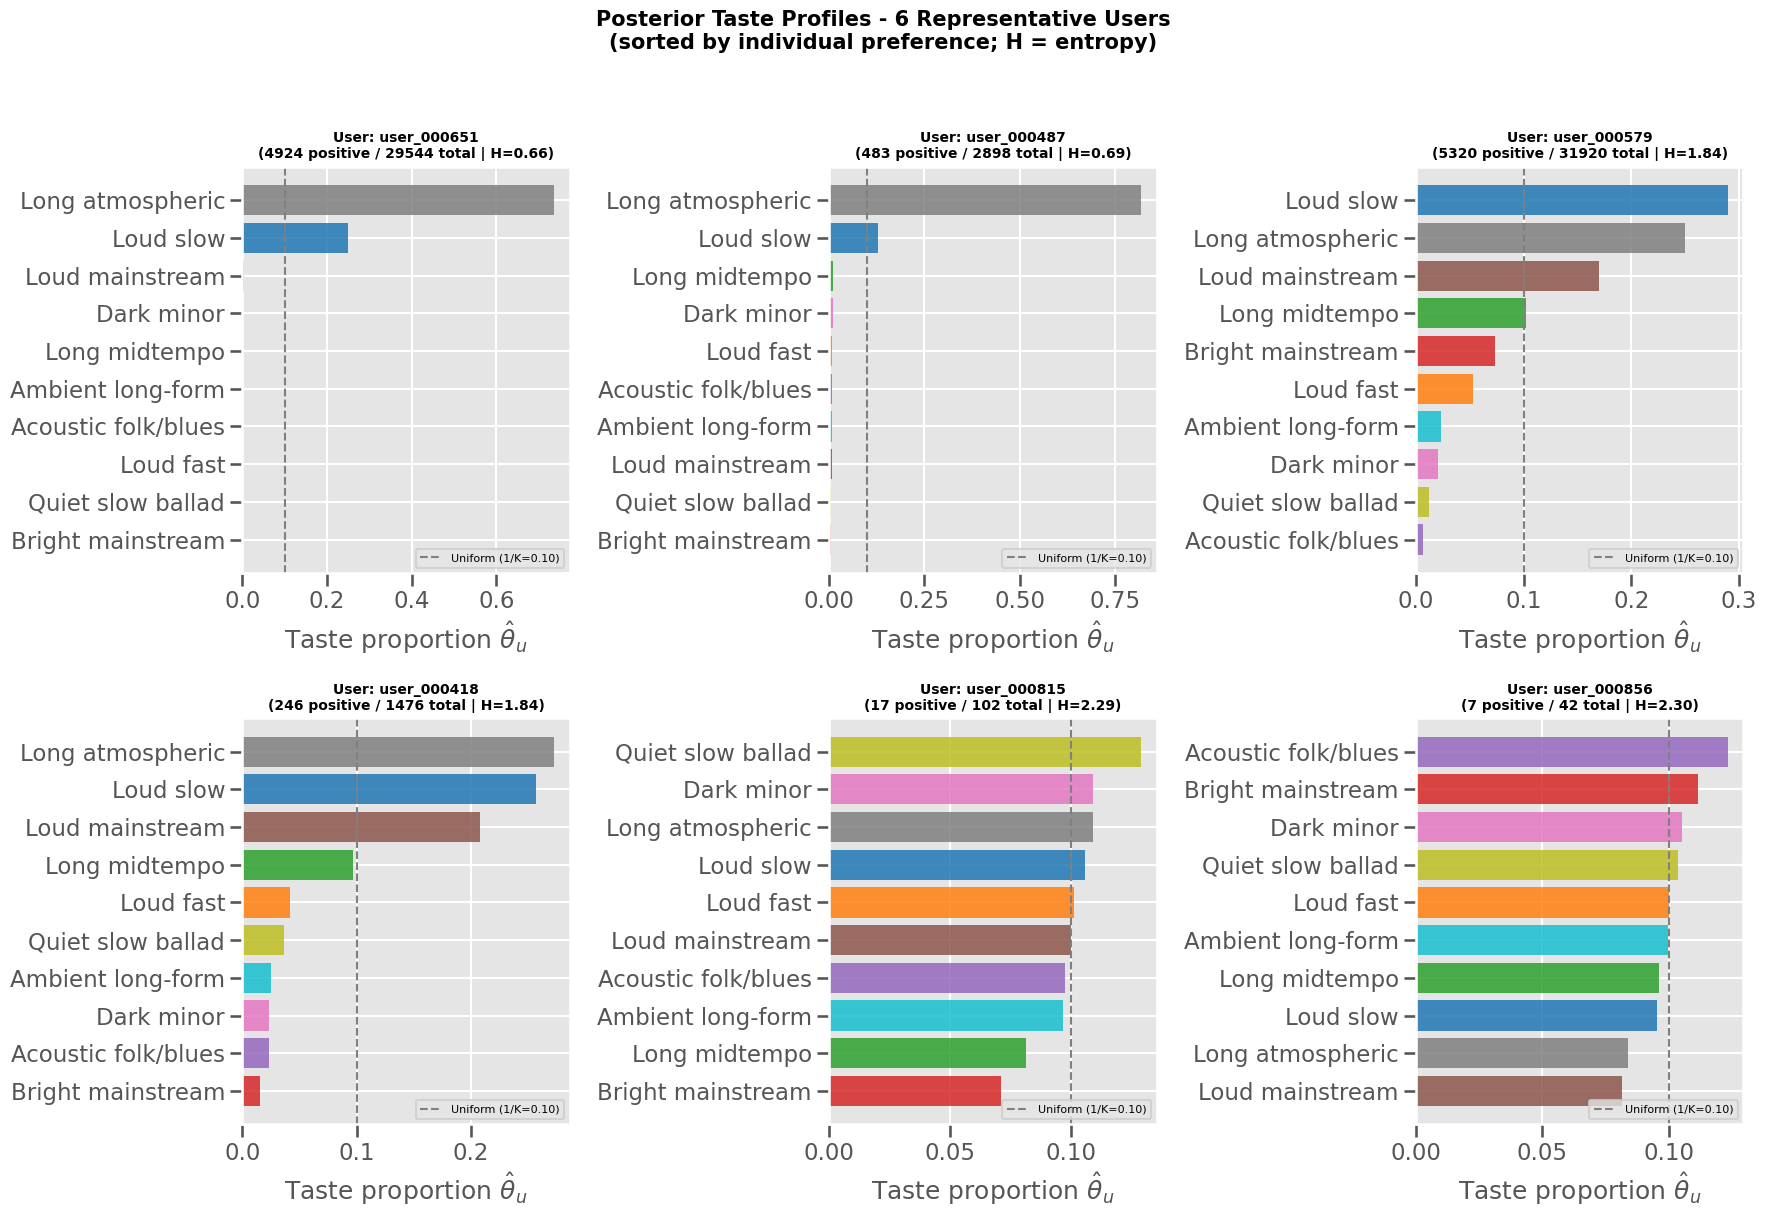

In [11]:
sorted_by_entropy = np.argsort(entropy)
picks = np.concatenate([
    sorted_by_entropy[:2],
    sorted_by_entropy[len(sorted_by_entropy)//2 - 1 : len(sorted_by_entropy)//2 + 1],
    sorted_by_entropy[-2:],
])

palette = sns.color_palette('tab10', K)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, u_idx in zip(axes, picks):
    theta_u   = theta_post[u_idx]
    user_id   = users[u_idx]
    n_pos     = int((df_listens[(df_listens['user_idx'] == u_idx) &
                                (df_listens['listened'] == 1)].shape[0]))
    n_total   = int((df_listens['user_idx'] == u_idx).sum())

    sort_idx = np.argsort(theta_u)
    labels   = [MOOD_NAMES[i] for i in sort_idx]
    values   = theta_u[sort_idx]
    colors   = [palette[i] for i in sort_idx]

    ax.barh(labels, values, color=colors, alpha=0.85)
    ax.axvline(1/K, color='grey', ls='--', lw=1.5, label=f'Uniform (1/K={1/K:.2f})')
    ax.set_xlabel('Taste proportion $\\hat{\\theta}_u$')
    ax.set_title(f'User: {user_id}\n'
                 f'({n_pos} positive / {n_total} total | H={entropy[u_idx]:.2f})',
                 fontsize=10, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)

fig.suptitle('Posterior Taste Profiles - 6 Representative Users\n'
             '(sorted by individual preference; H = entropy)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.1  Population-level taste heatmap

Mean posterior $\hat{\boldsymbol{\theta}}_u$ per dominant-mood group. A strong diagonal
confirms users concentrate on their dominant mood; off-diagonal spread indicates
secondary preferences.

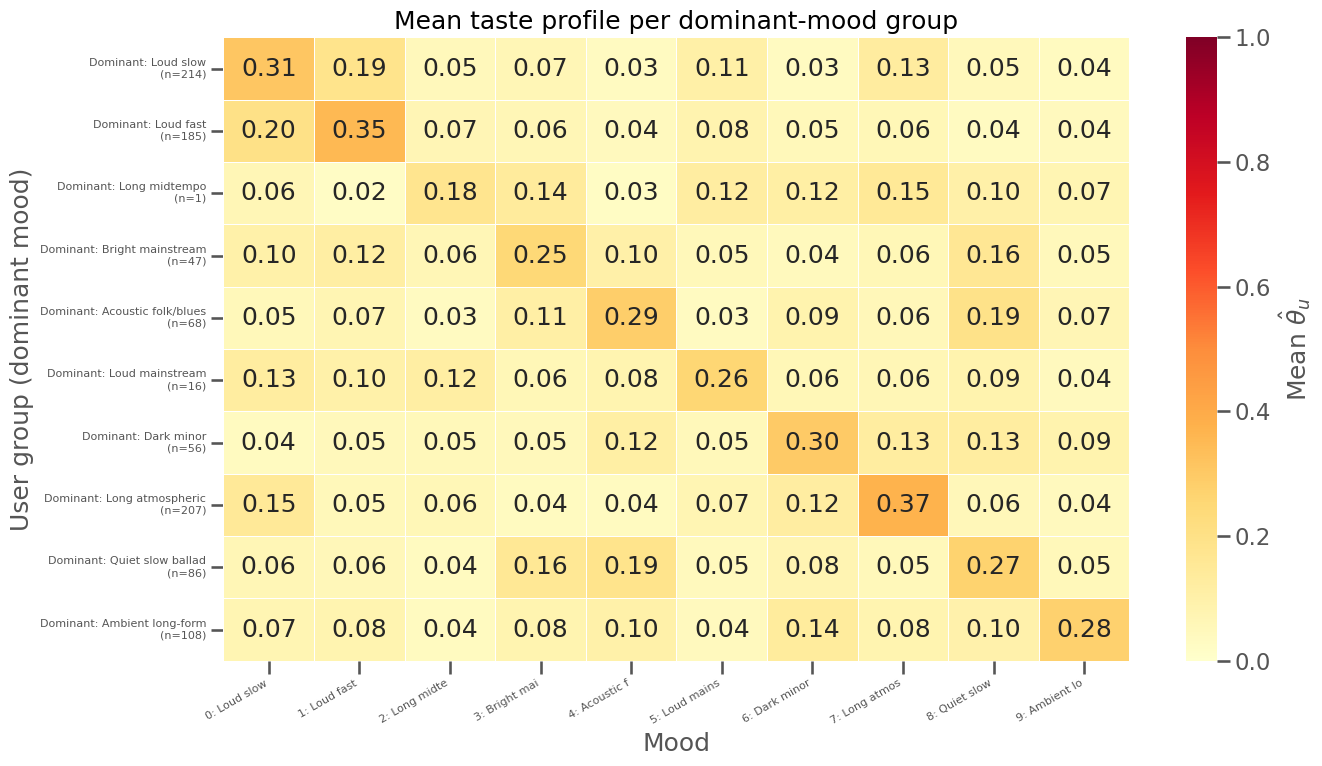

Group sizes (users per dominant mood):
  Mood  0 - Loud slow             :  214 users (21.7%)
  Mood  1 - Loud fast             :  185 users (18.7%)
  Mood  2 - Long midtempo         :    1 users (0.1%)
  Mood  3 - Bright mainstream     :   47 users (4.8%)
  Mood  4 - Acoustic folk/blues   :   68 users (6.9%)
  Mood  5 - Loud mainstream       :   16 users (1.6%)
  Mood  6 - Dark minor            :   56 users (5.7%)
  Mood  7 - Long atmospheric      :  207 users (21.0%)
  Mood  8 - Quiet slow ballad     :   86 users (8.7%)
  Mood  9 - Ambient long-form     :  108 users (10.9%)


In [12]:
dominant_mood = np.argmax(theta_post, axis=1)

group_means = np.zeros((K, K))
group_sizes = np.zeros(K, dtype=int)
for k in range(K):
    mask = dominant_mood == k
    group_sizes[k] = mask.sum()
    if mask.sum() > 0:
        group_means[k] = theta_post[mask].mean(axis=0)

row_labels = [f'Dominant: {MOOD_NAMES[k]}\n(n={group_sizes[k]})' for k in range(K)]
col_labels = [f'{k}: {MOOD_NAMES[k][:10]}' for k in range(K)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(group_means, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
            xticklabels=col_labels, yticklabels=row_labels,
            vmin=0, vmax=1, cbar_kws={'label': 'Mean $\\hat{\\theta}_u$'},
            linewidths=0.5)
ax.set_xlabel('Mood')
ax.set_ylabel('User group (dominant mood)')
ax.set_title('Mean taste profile per dominant-mood group')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print("Group sizes (users per dominant mood):")
for k in range(K):
    print(f"  Mood {k:2d} - {MOOD_NAMES[k]:<22s}: {group_sizes[k]:>4d} users "
          f"({group_sizes[k]/U*100:.1f}%)")

### 7.2  Dominant mood distribution across users

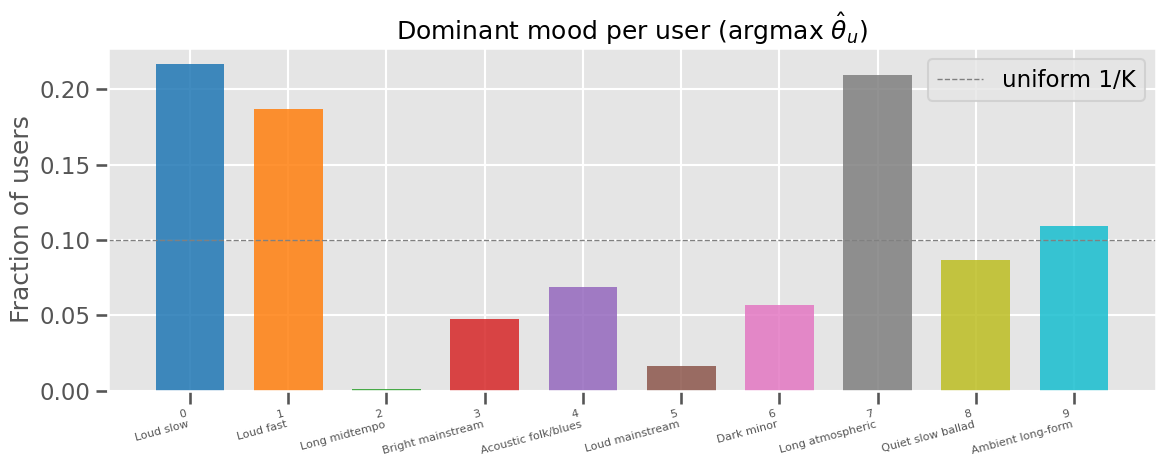

In [13]:
dominant_counts = np.bincount(dominant_mood, minlength=K)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(K), dominant_counts / U, color=palette, alpha=0.85, width=0.7)
ax.set_xticks(range(K))
ax.set_xticklabels([f'{k}\n{MOOD_NAMES[k]}' for k in range(K)],
                   fontsize=8, rotation=15, ha='right')
ax.set_ylabel('Fraction of users')
ax.set_title('Dominant mood per user (argmax $\\hat{\\theta}_u$)')
ax.axhline(1/K, color='grey', ls='--', lw=1, label='uniform 1/K')
ax.legend()
plt.tight_layout()
plt.show()

## 8  Phase 3 gate summary

Gate conditions:
1. **Converged** - tail slope satisfies the relative criterion $|\text{slope}| < |\overline{\mathcal{L}}| \times 10^{-5}$
2. **Taste signal present** - learned $\beta > 1$ (mood preference contributes meaningfully to the logit)
3. **Concentrated users** - ≥ 5 % of users have posterior entropy < 75 % of uniform
4. **Diffuse users** - ≥ 5 % of users have posterior entropy > 90 % of uniform

In [ ]:
converged3        = abs(slope3) < abs(tail3.mean()) * 1e-5
taste_signal_ok   = beta_final > 1.0
frac_concentrated = (entropy < uniform_entropy * 0.75).mean()
frac_diffuse      = (entropy > uniform_entropy * 0.90).mean()

print("=" * 70)
print("PHASE 3 GATE SUMMARY - user-taste extension (fixed)")
print("=" * 70)
print(f"Users modelled (≥5 positive listens):  {U}")
print(f"Listen events:                         {len(df_listens):,}")
print(f"K (moods from Phase 1):                {K}")
print(f"Final ELBO loss:                       {losses3[-1]:,.0f}")
print(f"Slope (last 200 steps):                {slope3:+.3f}")
print(f"Convergence threshold (|ELBO|×1e-5):   {abs(tail3.mean())*1e-5:.3f}")
print(f"SVI converged:                         {converged3}")
print(f"Learned taste_scale β:                 {beta_final:.4f}  (need > 1)")
print(f"Taste signal present (β > 1):          {taste_signal_ok}")
print(f"Posterior entropy (median):            {np.median(entropy):.3f}  (uniform={uniform_entropy:.3f})")
print(f"Users with concentrated taste:         {frac_concentrated*100:.1f}%  (> 5% needed)")
print(f"Users with diffuse taste:              {frac_diffuse*100:.1f}%  (> 5% needed)")

gate_pass = converged3 and taste_signal_ok and frac_concentrated > 0.05 and frac_diffuse > 0.05
print(f"\nPhase 3 gate: {'PASS' if gate_pass else 'FAIL'}")

PHASE 3 GATE SUMMARY - user-taste extension (fixed)
Users modelled (≥5 positive listens):  988
Listen events:                         16,810,698
K (moods from Phase 1):                10
Final ELBO loss:                       5,593,554
Slope (last 200 steps):                -7.016
Convergence threshold (|ELBO|×1e-5):   55.942
SVI converged:                         True
Learned taste_scale β:                 3.4989  (need > 1)
Taste signal present (β > 1):          True
Posterior entropy (median):            1.839  (uniform=2.303)
Users with concentrated taste:         36.5%  (> 5% needed)
Users with diffuse taste:              15.7%  (> 5% needed)

Phase 3 gate: PASS


: 